In [1]:
import PythonicDISORT
import disort
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

# PythonicDISORT

In [2]:
######################################### PYDISORT ARGUMENTS #######################################

tau_arr = 5
omega_arr = 0.5
NQuad = 16
Leg_coeffs_all = np.zeros(17)
Leg_coeffs_all[0] = 1
Leg_coeffs_all[2] = 0.1
mu0 = 0.080442
I0 = pi
phi0 = 0

# Optional (used)

# Optional (unused)
NLeg=None
NLoops=None
b_pos=0
b_neg=0
only_flux=False
f_arr=0
NT_cor=False
Leg_coeffs_BDRF=np.array([])
s_poly_coeffs=np.array([[]])
use_sparse_NLayers=6

####################################################################################################

In [3]:
# Call pydisort function
mu_arr, flux_up, flux_down, u = PythonicDISORT.pydisort(
    tau_arr, omega_arr,
    NQuad,
    Leg_coeffs_all,
    mu0, I0, phi0,
)

## Setup for tests

In [4]:
# mu_arr is arranged as it is for code efficiency and readability
# For presentation purposes we re-arrange mu_arr from smallest to largest
reorder_mu = np.argsort(mu_arr)
mu_arr_RO = mu_arr[reorder_mu]

# By default we do not compare intensities 10 degree around the direct beam
deg_around_beam_to_not_compare = 10  # This parameter changes the size of the region
mu_to_compare = (
    np.abs(np.arccos(np.abs(mu_arr_RO)) - np.arccos(mu0)) * 180 / pi
    > deg_around_beam_to_not_compare
)
mu_test_arr_RO = mu_arr_RO[mu_to_compare]

#mu_around_beam_to_not_compare = 0.1
#mu_to_compare = np.abs(np.abs(mu_arr_RO) - mu0) > mu_around_beam_to_not_compare
#mu_test_arr_RO = mu_arr_RO[mu_to_compare]"""

In [5]:
# Number of phi grid points
# This selection should ensure that the phi quadrature is at least as accurate as the mu quadrature
Nphi = int((NQuad * pi) // 2) * 2 + 1
phi_arr, full_weights_phi = PythonicDISORT.subroutines.Clenshaw_Curtis_quad(Nphi)

Ntau = 1000 # Number of tau test points
tau_test_arr = np.random.random(Ntau) * tau_arr

MU_ARR, PHI_ARR = np.meshgrid(phi_arr, mu_arr_RO)

## Stamnes' DISORT

In [6]:
# Stamnes' DISORT arguments
nlyr = 1
nmom = NLeg
nstr = NQuad
numu = NQuad
nphi = Nphi
ntau = Ntau
usrang = True
usrtau = True
ibcnd = 0
onlyfl = False
prnt = np.array([False, False, False, False, False])  # Prints to CMD instead of this notebook
plank = False
lamber = True
deltamplus = False
do_pseudo_sphere = False
dtauc = tau_arr
ssalb = omega_arr
pmom = Leg_coeffs_all.T
temper = np.zeros(nlyr + 1)
wvnmlo = 0
wvnmhi = 0
utau = tau_test_arr
umu0 = mu0
phi0 = phi0
umu = mu_arr_RO
phi = phi_arr
fbeam = I0
fisot = 0
albedo = 0
btemp = 0
ttemp = 0
temis = 0
earth_radius = 6371
h_lyr = np.zeros(nlyr + 1)
rhoq = np.zeros((nstr // 2, nstr + 1, nstr))
rhou = np.zeros((numu, nstr // 2 + 1, nstr))
rho_accurate = np.zeros((numu, nphi))
bemst = np.zeros(nstr // 2)
emust = np.zeros(numu)
accur = 0
header = ""
rfldir = np.zeros(ntau)
rfldn = np.zeros(ntau)
flup = np.zeros(ntau)
dfdt = np.zeros(ntau)
uavg = np.zeros(ntau)
uu = np.zeros((numu, ntau, nphi))
albmed = np.zeros(numu)
trnmed = np.zeros(numu)

In [7]:
# Run disort, putting DFDT, UAVG, and UU in a, b, and c, respectively
rfldir, rfldn, flup, dfdt, uavg, uu, albmed, trnmed = disort.disort(usrang, usrtau, ibcnd, onlyfl, prnt, plank, lamber, deltamplus, do_pseudo_sphere, dtauc, ssalb,
                        pmom, temper, wvnmlo, wvnmhi, utau, umu0, phi0 * 180/pi, umu, phi * 180/pi, fbeam, fisot, albedo, btemp, ttemp,
                        temis, earth_radius, h_lyr, rhoq, rhou, rho_accurate, bemst, emust, accur, header, rfldir,
                        rfldn, flup, dfdt, uavg, uu, albmed, trnmed)

In [8]:
print("Max pointwise differences")
print()

# Upward (diffuse) fluxes
print("Upward (diffuse) fluxes")
diff_flux_up = np.abs(flup - flux_up(tau_test_arr))
ratio_flux_up = diff_flux_up / np.clip(flup, a_min=1e-6, a_max=None)
print("Difference =", np.max(diff_flux_up))
print("Difference ratio =", np.max(ratio_flux_up))
print()

# Downward (diffuse) fluxes
print("Downward (diffuse) fluxes")
diff_flux_down_diffuse = np.abs(rfldn - flux_down(tau_test_arr)[0])
ratio_flux_down_diffuse = diff_flux_down_diffuse / np.clip(
    rfldn, a_min=1e-6, a_max=None
)
print("Difference =", np.max(diff_flux_down_diffuse))
print(
    "Difference ratio =",
    np.max(ratio_flux_down_diffuse),
)
print()

# Direct (downward) fluxes
print("Direct (downward) fluxes")
diff_flux_down_direct = np.abs(rfldir - flux_down(tau_test_arr)[1])
ratio_flux_down_direct = diff_flux_down_direct / np.clip(rfldir, a_min=1e-6, a_max=None)
print("Difference =", np.max(diff_flux_down_direct))
print(
    "Difference ratio =",
    np.max(ratio_flux_down_direct),
)

Max pointwise differences

Upward (diffuse) fluxes
Difference = 9.493090223633427e-09
Difference ratio = 2.063461135193047e-05

Downward (diffuse) fluxes
Difference = 1.4390382940820956e-08
Difference ratio = 7.342778677641983e-05

Direct (downward) fluxes
Difference = 2.538887386438482e-08
Difference ratio = 1.137379519077266e-06


In [9]:
diff = np.abs(uu - u(tau_test_arr, phi_arr)[reorder_mu])[mu_to_compare]
diff_ratio = diff / np.clip(uu[mu_to_compare], a_min=1e-6, a_max=None)

In [10]:
max_diff_tau_index = np.argmax(np.max(np.max(diff, axis=0), axis=1))
max_ratio_tau_index = np.argmax(np.max(np.max(diff_ratio, axis=0), axis=1))

# Plots will be created for only these values of tau
diff_tau_pt = tau_test_arr[max_diff_tau_index]
ratio_tau_pt = tau_test_arr[max_ratio_tau_index]

In [11]:
print("At tau = " + str(diff_tau_pt))
print("Max pointwise difference =", np.max(diff[:, max_diff_tau_index, :]))
print("At tau = " + str(ratio_tau_pt))
print("Max pointwise difference ratio =", np.max(diff_ratio[:, max_ratio_tau_index, :]))

At tau = 0.17320191628388826
Max pointwise difference = 1.061968253265877e-08
At tau = 0.0002345359573935335
Max pointwise difference ratio = 1.8129711925580264e-05


**Does the test pass?**

In [12]:
assert np.max(ratio_flux_up) <= 1e-3 or np.max(diff_flux_up) <= 1e-2 / pi
assert np.max(ratio_flux_down_diffuse) <= 1e-3 or np.max(diff_flux_down_diffuse) <= 1e-2 / pi
assert np.max(ratio_flux_down_direct) <= 1e-3 or np.max(diff_flux_down_direct) <= 1e-2 / pi
assert np.max(diff_ratio) <= 1e-2 or np.max(diff) <= 1e-2

print("The test passes")

The test passes


In [13]:
STOP

NameError: name 'STOP' is not defined

# Save outputs

In [14]:
np.savez(
    "Stamnes_results/2c_test",
    phi_arr=phi_arr,
    tau_test_arr=tau_test_arr,
    uu=uu,
    flup=flup,
    rfldn=rfldn,
    rfldir=rfldir,
)

# Diagnostic plots

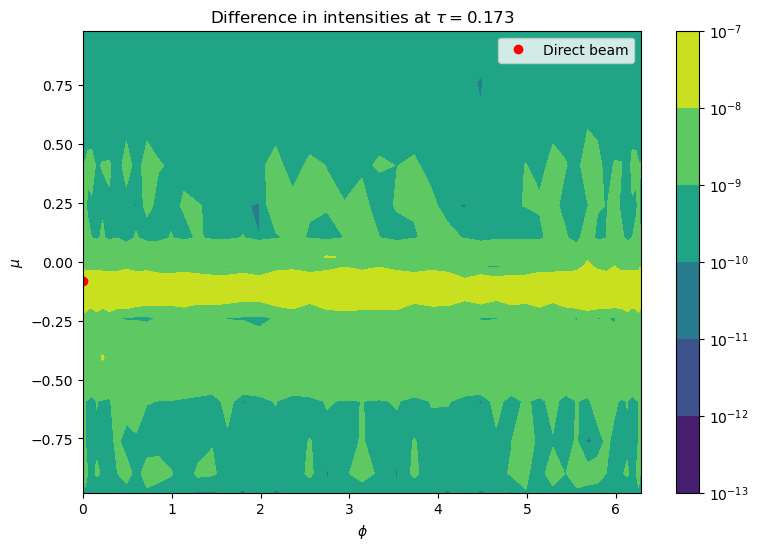

In [15]:
diff_plot = np.abs(uu - u(tau_test_arr, phi_arr)[reorder_mu])
plot = diff_plot[:, max_diff_tau_index, :]

fig = plt.figure(figsize=(9, 6))
_contourf = plt.contourf(MU_ARR, PHI_ARR, plot, norm=mpl.colors.LogNorm())
plt.plot(phi0, -mu0, "o", color="red", label="Direct beam")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\mu$")
plt.colorbar(_contourf)
plt.title(r"Difference in intensities at $\tau =$" + str(np.around(diff_tau_pt, 3)))
plt.legend()

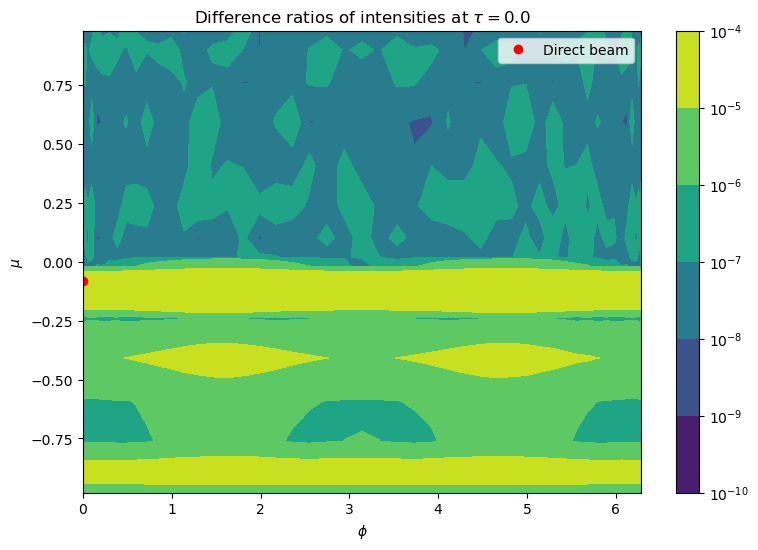

In [16]:
diff_ratio_plot = diff_plot / np.clip(uu, a_min=1e-6, a_max=None)
plot = diff_ratio_plot[:, max_ratio_tau_index, :]

fig = plt.figure(figsize=(9, 6))
_contourf = plt.contourf(MU_ARR, PHI_ARR, plot, norm=mpl.colors.LogNorm())
plt.plot(phi0, -mu0, "o", color="red", label="Direct beam")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\mu$")
plt.colorbar(_contourf)
plt.title(r"Difference ratios of intensities at $\tau =$" + str(np.around(ratio_tau_pt, 3)))
plt.legend()